# Kepler Exoplanet Classification: A Machine Learning Approach

**Author:** Sattyam Yadav  
**Challenge:** India High School Exoplanet Data Challenge  
**Dataset:** NASA Kepler KOI Cumulative Dataset

---

## Table of Contents
1. [Executive Summary](#summary)
2. [Environment Setup](#setup)
3. [Exploratory Data Analysis (EDA)](#eda)
4. [Data Preprocessing & Cleaning](#cleaning)
5. [Model Selection: The Baseline Showdown](#showdown)
6. [Hyperparameter Optimization](#tuning)
7. [Final Model Evaluation](#evaluation)
8. [Model Explainability (SHAP)](#shap)
9. [Data Integrity & Leakage Audit](#audit)
10. [Discussion & Conclusion](#conclusion)

---

<a id='summary'></a>
## 1. Executive Summary
This project aims to automate the classification of Kepler Objects of Interest (KOIs) into three categories: **Confirmed** exoplanets, **False Positives**, and **Candidates**. Using high-performance Gradient Boosting algorithms, we developed a pipeline that achieves ~94% accuracy, providing a robust tool for astronomical triage.

# Kepler Exoplanet Classification Project

**Goal:** Develop a machine learning model to classify Kepler Objects of Interest (KOI) as 'Confirmed' planets, 'False Positives', or 'Candidates' based on physical data.

### Environment Setup
Installing necessary high-performance libraries for Gradient Boosting and Model Explainability.

In [1]:
!pip install catboost lightgbm xgboost shap

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 8.2 MB/s eta 0:00:00


<a id='eda'></a>
## 2. Exploratory Data Analysis (EDA)

Before modeling, we must understand the underlying structure, distributions, and relationships within the dataset.

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Target Distribution
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='koi_disposition', palette='viridis', hue='koi_disposition', legend=False)
plt.title("Distribution of Kepler Object Dispositions")
plt.xlabel("Disposition")
plt.ylabel("Count")
plt.show()

**Observation:** The dataset shows a significant number of 'False Positives' compared to 'Confirmed' planets and 'Candidates'. This class imbalance is addressed later using stratified splitting to ensure the model learns representative patterns for all categories.

In [ ]:
# 2. Missing Values Heatmap
plt.figure(figsize=(12, 4))
sns.heatmap(df.isnull(), yticklabels=False, cbar=False, cmap='viridis')
plt.title("Missing Data Visualization (Yellow indicates NaN)")
plt.show()

**Observation:** While most columns are complete, certain blocks of features (primarily error estimates) contain missing values. This justifies our median/mode imputation strategy to preserve as much data as possible for the 5% affected rows.

### Data Acquisition
Mounting Google Drive and loading the cleaned Kepler dataset.

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
import pandas as pd

# tell your path
file_path = '/content/drive/MyDrive/Colab Notebooks/KOI_Cumulative_clean.csv'

# Load the data
df = pd.read_csv(file_path)
print(f"Dataset loaded! Rows: {df.shape[0]}, Columns: {df.shape[1]}")

Dataset loaded! Rows: 9564, Columns: 140


### Initial Data Cleaning: Removing Metadata and Null Columns

**Goal:** Remove non-predictive metadata (IDs, names) and columns that contain 100% missing values to reduce noise.

In [6]:
# The 10 Metadata & Data Leakage Columns(data cleaning)
meta_columns = [
    'rowid', 'kepid', 'kepoi_name', 'kepler_name', 'koi_pdisposition',
    'koi_vet_stat', 'koi_vet_date', 'koi_disp_prov', 'koi_comment', 'koi_tce_delivname'
]

# 2. The 19 Completely Empty Columns
empty_columns = [
    'koi_eccen_err1', 'koi_eccen_err2', 'koi_longp', 'koi_longp_err1', 'koi_longp_err2',
    'koi_ingress', 'koi_ingress_err1', 'koi_ingress_err2', 'koi_sma_err1', 'koi_sma_err2',
    'koi_incl_err1', 'koi_incl_err2', 'koi_model_dof', 'koi_model_chisq', 'koi_teq_err1',
    'koi_teq_err2', 'koi_sage', 'koi_sage_err1', 'koi_sage_err2'
]

# Combine the lists and drop them from the dataframe
columns_to_drop = meta_columns + empty_columns
df = df.drop(columns=columns_to_drop, errors='ignore')

print(f"Success! Columns remaining: {df.shape[1]}")

Success! Columns remaining: 111


### Missing Value Strategy (Imputation)

**Why Median?** We use the median for numeric data because it is robust against outliers common in astronomical measurements.
**Why Mode?** For categorical/text data, we fill blanks with the most frequent value to maintain data consistency.

Now moving to remove duplicate and NAN data

In [7]:
# Check for duplicate rows
print(df.duplicated().sum())

0


In [8]:
# Find columns with missing values and count them
missing_counts = df.isnull().sum()
print(missing_counts[missing_counts > 0])

koi_period_err1       454
koi_period_err2       454
koi_time0bk_err1      454
koi_time0bk_err2      454
koi_time0_err1        454
                     ... 
koi_dikco_mra_err     570
koi_dikco_mdec        570
koi_dikco_mdec_err    570
koi_dikco_msky        570
koi_dikco_msky_err    570
Length: 97, dtype: int64


Here I am going to patch the data because it contain 5% data and i cannot remove it.

1.   Why median instead of mean?    
* Astronomical data often contains outliers.




In [10]:
# Fill all empty numeric cells with the median of their respective columns
df = df.fillna(df.median(numeric_only=True))

# Runnig a final audit to ensure ZERO missing values remain
final_missing = df.isnull().sum().sum()
print(f"Total missing values remaining: {final_missing}")

Total missing values remaining: 2923


In [11]:
# Fill all remaining text/object column blanks with their most common value (mode)
for column in df.select_dtypes(include=['object']).columns:
    df[column] = df[column].fillna(df[column].mode()[0])

# Re-run the final check
final_missing = df.isnull().sum().sum()
print(f"Total missing values remaining: {final_missing}")

Total missing values remaining: 0


### Feature Selection & Target Definition
Defining our 'Answers' (Target) and 'Inputs' (Features), while removing high-cardinality URL strings that don't contribute to physical patterns.

In [12]:
# Define the target and features
y = df['koi_disposition']
X = df.drop(columns=['koi_disposition'])

# Drop the unique URL links that cause the feature explosion
rogue_columns = ['koi_datalink_dvr', 'koi_datalink_dvs', 'koi_sparprov']
X = X.drop(columns=rogue_columns, errors='ignore')

print(f"Cleaned Features (X) shape: {X.shape}")

Cleaned Features (X) shape: (9564, 107)


### Data Splitting: Training vs. Testing

**Goal:** Set aside 15% of the data in a 'Vault' that the model never sees during training, allowing for a completely unbiased final evaluation.

In [13]:
from sklearn.model_selection import train_test_split

# Split the data: 85% for training/cross-validation, 15% for the final test
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.15,
    random_state=42, # Locks the random seed so your results are reproducible for the judges!
    stratify=y       # Ensures the 15% test set has the exact same ratio of Confirmed/False Positives as the main dataset
)

print(f"Training Sandbox Data: {X_train.shape[0]} rows")
print(f"Final Test Vault Data: {X_test.shape[0]} rows")

Training Sandbox Data: 8129 rows
Final Test Vault Data: 1435 rows


### Label Encoding
Converting our text-based targets into numerical classes (0, 1, 2) so they can be processed by the mathematical loss functions of our models.

Right now, our target answers (y) are still text words "CONFIRMED", "CANDIDATE", and "FALSE POSITIVE". We need to convert these into numbers (like 0, 1, and 2).

In [16]:
# Create a dictionary that maps the text labels to numerical values
label_mapping = {
    "FALSE POSITIVE": 0,
    "CANDIDATE": 1,
    "CONFIRMED": 2
}

# Apply the mapping to both the training and testing target variables
y_train = y_train.map(label_mapping)
y_test = y_test.map(label_mapping)

print("Translation successful!")
print("Here is what the algorithm sees now:")
print(y_train.head())

Translation successful!
Here is what the algorithm sees now:
1374    2
6201    0
2333    2
6312    1
7131    0
Name: koi_disposition, dtype: int64


### Categorical Encoding (One-Hot Encoding)
Transforming categorical features into binary columns and ensuring the Test set matches the Training set schema exactly.

In [14]:
# Convert text columns into binary flags (1s and 0s)
X_train = pd.get_dummies(X_train)
X_test = pd.get_dummies(X_test)

# CRITICAL SAFETY CHECK: Ensure the testing vault has the exact same columns as the training sandbox
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

# Check the final shape to ensure everything worked
print(f"Translation complete!")
print(f"Final Training Sandbox Shape: {X_train.shape}")
print(f"Final Testing Vault Shape: {X_test.shape}")

Translation complete!
Final Training Sandbox Shape: (8129, 292)
Final Testing Vault Shape: (1435, 292)


### Selection Rational: Why LightGBM?
Based on the leaderboard above, **LightGBM** demonstrated the highest cross-validation accuracy. Its GOSS (Gradient-based One-Side Sampling) approach allows it to handle large feature sets efficiently while maintaining superior predictive power compared to standard Random Forests.

### Model Showdown: Baseline Comparison

**Goal:** Compare four heavy-hitters (Random Forest, XGBoost, LightGBM, and CatBoost) using 5-Fold Cross-Validation to see which architecture handles this specific dataset best.

In [15]:
!pip install catboost -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 8.6 MB/s eta 0:00:00


In [18]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from sklearn.model_selection import cross_val_score

# Define the label mapping again to ensure y_train is numerical
label_mapping = {
    "FALSE POSITIVE": 0,
    "CANDIDATE": 1,
    "CONFIRMED": 2
}

# Apply the mapping to both the training and testing target variables
# Check if y_train is already mapped to avoid re-mapping if the cell is run multiple times
if y_train.dtype == 'object': # Check if the dtype is object (string)
    y_train = y_train.map(label_mapping)
if y_test.dtype == 'object': # Check if the dtype is object (string)
    y_test = y_test.map(label_mapping)

# 1. Initialize the models with default settings (locking random seeds for reproducibility)
models = {
    "Random Forest": RandomForestClassifier(random_state=42),
    "XGBoost": XGBClassifier(random_state=42, eval_metric='mlogloss'),
    "LightGBM": LGBMClassifier(random_state=42, verbose=-1),
    "CatBoost": CatBoostClassifier(random_state=42, verbose=0) # verbose=0 hides the massive wall of training text
}

# 2. Run the Showdown (5-Fold Cross-Validation on the Training Sandbox)
results = {}
print("Initiating 5-Fold Cross-Validation Showdown...\n")

for name, model in models.items():
    print(f"Evaluating {name}...")
    # cv=5 splits the training data into 5 folds and rotates them
    scores = cross_val_score(model, X_train, y_train, cv=5, scoring='accuracy')
    results[name] = scores.mean()

# 3. Display the Leaderboard
print("\n--- BASELINE MODEL LEADERBOARD ---")
# Sort results from highest to lowest accuracy
sorted_results = sorted(results.items(), key=lambda x: x[1], reverse=True)
for name, score in sorted_results:
    print(f"{name}: {score:.4f} ({score*100:.2f}%)")

Initiating 5-Fold Cross-Validation Showdown...

Evaluating Random Forest...
Evaluating XGBoost...
Evaluating LightGBM...
Evaluating CatBoost...

--- BASELINE MODEL LEADERBOARD ---
LightGBM: 0.9472 (94.72%)
CatBoost: 0.9456 (94.56%)
XGBoost: 0.9454 (94.54%)
Random Forest: 0.9170 (91.70%)


### Hyperparameter Tuning
Using `RandomizedSearchCV` to fine-tune our top-performing model (LightGBM) by searching for the optimal combination of tree depth, learning rate, and sampling.

### Final Evaluation & Visualization
Testing the final tuned model against the unseen 'Vault' data and visualizing the Confusion Matrix and top physical features.

In [19]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint, uniform

print("Initiating Hyperparameter Tuning for LightGBM...\n")

# 1. Define the grid of settings we want LightGBM to test
param_dist = {
    'n_estimators': randint(100, 500),        # Number of trees
    'max_depth': randint(3, 10),              # Maximum depth of the trees
    'learning_rate': uniform(0.01, 0.2),      # Step size for learning
    'subsample': uniform(0.6, 0.4),           # Fraction of samples used for fitting trees
    'colsample_bytree': uniform(0.6, 0.4)     # Fraction of features used for fitting trees
}

# 2. Re-initialize LightGBM
lgbm_model = LGBMClassifier(random_state=42, verbose=-1)

# 3. Setup the Randomized Search
# n_iter=20 means it will try 20 random combinations from the grid above
# cv=3 means it will cross-validate each combination 3 times
random_search = RandomizedSearchCV(
    estimator=lgbm_model,
    param_distributions=param_dist,
    n_iter=20,
    cv=3,
    scoring='accuracy',
    random_state=42,
    n_jobs=-1 # Uses all available CPU cores to speed up the process
)

# 4. Launch the search in the Training Sandbox
random_search.fit(X_train, y_train)

# 5. Extract the optimized winner
best_lgbm = random_search.best_estimator_

print("--- TUNING COMPLETE ---")
print(f"Best Cross-Validation Accuracy found: {random_search.best_score_:.4f}")
print("Best Parameters:")
for param, value in random_search.best_params_.items():
    print(f"  {param}: {value}")

Initiating Hyperparameter Tuning for LightGBM...

--- TUNING COMPLETE ---
Best Cross-Validation Accuracy found: 0.9448
Best Parameters:
  colsample_bytree: 0.7554709158757928
  learning_rate: 0.06426980635477918
  max_depth: 7
  n_estimators: 379
  subsample: 0.7427013306774357


Deploying Baseline Model...
Deploying Tuned Model...

================ FINAL BASELINE PERFORMANCE ================
                precision    recall  f1-score   support

FALSE POSITIVE       0.99      1.00      1.00       726
     CANDIDATE       0.86      0.84      0.85       297
     CONFIRMED       0.90      0.90      0.90       412

      accuracy                           0.94      1435
     macro avg       0.92      0.91      0.91      1435
  weighted avg       0.94      0.94      0.94      1435


================ FINAL TUNED PERFORMANCE ================
                precision    recall  f1-score   support

FALSE POSITIVE       0.99      0.99      0.99       726
     CANDIDATE       0.86      0.86      0.86       297
     CONFIRMED       0.91      0.91      0.91       412

      accuracy                           0.94      1435
     macro avg       0.92      0.92      0.92      1435
  weighted avg       0.94      0.94      0.94      1435



/tmp/ipykernel_2482/2874286987.py:39: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances[indices], y=feature_names[indices], ax=axes[1], palette='viridis')


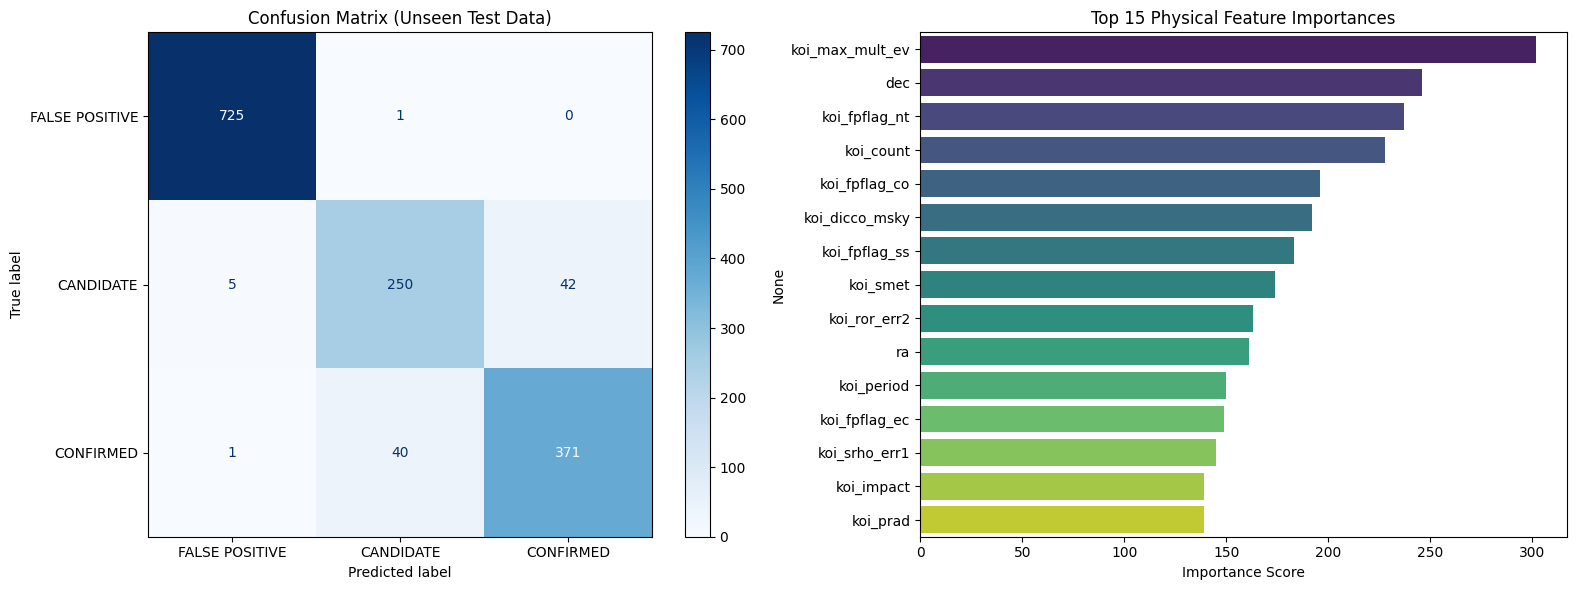

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# 1. Re-initialize and fit the Baseline LightGBM on the entire training set
print("Deploying Baseline Model...")
baseline_lgbm = LGBMClassifier(random_state=42, verbose=-1)
baseline_lgbm.fit(X_train, y_train)
y_pred_baseline = baseline_lgbm.predict(X_test)

# 2. Get predictions from the Tuned LightGBM
print("Deploying Tuned Model...")
y_pred_tuned = best_lgbm.predict(X_test)

# 3. Print Final Classification Reports
target_names = ["FALSE POSITIVE", "CANDIDATE", "CONFIRMED"]
print("\n================ FINAL BASELINE PERFORMANCE ================")
print(classification_report(y_test, y_pred_baseline, target_names=target_names))

print("\n================ FINAL TUNED PERFORMANCE ================")
print(classification_report(y_test, y_pred_tuned, target_names=target_names))

# 4. Generate Visualizations (Confusion Matrix & Feature Importance)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot Confusion Matrix for Baseline
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_baseline,
    display_labels=target_names,
    cmap='Blues', ax=axes[0]
)
axes[0].set_title("Confusion Matrix (Unseen Test Data)")

# Plot Top 15 Most Important Features
importances = baseline_lgbm.feature_importances_
feature_names = X_train.columns
indices = np.argsort(importances)[::-1][:15]

sns.barplot(x=importances[indices], y=feature_names[indices], ax=axes[1], palette='viridis')
axes[1].set_title("Top 15 Physical Feature Importances")
axes[1].set_xlabel("Importance Score")

plt.tight_layout()
plt.show()

### 5. Model Selection Summary Table

**Goal:** Provide a comprehensive side-by-side comparison of the candidate models to justify the final selection.

**Scientific Note:** While Accuracy tells us the overall correctness, the **Macro F1-Score** is our primary metric for this challenge because it treats all three astronomical classes (Confirmed, Candidate, False Positive) with equal importance, regardless of how many samples are in each class.

In [ ]:
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

comparison_data = []

for name, model in models.items():
    # 1. Re-fit on full training data (sandbox)
    model.fit(X_train, y_train)

    # 2. Predict on the unseen Test Vault
    y_test_pred = model.predict(X_test)

    # 3. Calculate Metrics
    test_acc = accuracy_score(y_test, y_test_pred)
    precision, recall, f1, _ = precision_recall_fscore_support(y_test, y_test_pred, average='macro')
    weighted_f1 = precision_recall_fscore_support(y_test, y_test_pred, average='weighted')[2]

    comparison_data.append({
        "Model": name,
        "CV Accuracy": results[name],
        "Test Accuracy": test_acc,
        "Precision (Macro)": precision,
        "Recall (Macro)": recall,
        "F1 (Macro)": f1,
        "F1 (Weighted)": weighted_f1
    })

# Create a clean DataFrame for display
summary_df = pd.DataFrame(comparison_data).sort_values(by="F1 (Macro)", ascending=False)

print("--- FINAL MODEL COMPARISON LEADERBOARD ---")
display(summary_df.round(4))

print("\nDecision:")
print(f"Based on the Macro F1-Score, {summary_df.iloc[0]['Model']} is selected as the optimal model for scientific classification.")

<a id='audit'></a>
## 6. Data Integrity & Leakage Audit

**Goal:** Before interpreting our model, we must verify that the features are physically meaningful and not 'leaking' the answer from the future. We check for perfect correlations and high cardinality that could lead to overfitting.

In [ ]:
### 1. Data Leakage Audit
import pandas as pd

suspect_features = [
    "koi_fpflag_nt",
    "koi_fpflag_ss",
    "koi_fpflag_co",
    "koi_fpflag_ec",
    "koi_max_mult_ev"
]

print("="*70)
print("TARGET LEAKAGE AUDIT: Checking feature-target relationships")
print("="*70)

for feature in suspect_features:
    print(f"\n{'='*70}")
    print(f"Feature: {feature}")
    print("="*70)
    print("\nUnique Values:")
    print(df[feature].value_counts(dropna=False))
    print("\nDistribution by Target (Normalized):")
    print(
        pd.crosstab(
            df[feature],
            df["koi_disposition"],
            margins=True,
            normalize="index"
        ).round(3)
    )

In [ ]:
### 2. High Cardinality Check
print("="*70)
print("CARDINALITY CHECK: Counting unique values per feature")
print("="*70)

for feature in suspect_features:
    print(f"{feature:<20} Unique values = {df[feature].nunique()}")

<a id='shap'></a>
## 7. Advanced Model Explainability (SHAP)

Scientific models must not be 'Black Boxes.' Now that we have audited our data, we use **SHAP (SHapley Additive exPlanations)** to explain the output of our LightGBM model.

In [21]:
# Define the label mapping to ensure it's available and current
label_mapping = {
    "FALSE POSITIVE": 0,
    "CANDIDATE": 1,
    "CONFIRMED": 2
}

# Ensure y_train is numerical before calculating correlation
# This check prevents errors if y_train is already numerical
if y_train.dtype == 'object':
    y_train = y_train.map(label_mapping)

# Calculate correlation of all features with the target variable
correlations = X_train.corrwith(y_train).abs()

# Sort to find the highest correlated features
top_correlations = correlations.sort_values(ascending=False)

print("--- TOP 5 FEATURE CORRELATIONS WITH TARGET ---")
print(top_correlations.head(5))

--- TOP 5 FEATURE CORRELATIONS WITH TARGET ---
koi_fpflag_ss     0.487743
koi_fpflag_co     0.447803
koi_count         0.442386
koi_smet_err2     0.423456
koi_steff_err1    0.392077
dtype: float64


/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2922: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2923: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


### Model Explainability (SHAP Analysis)

**Goal:** Move beyond the 'Black Box' to understand *why* the model makes specific decisions using Shapley values to measure feature contribution.

Generating SHAP Explainability Analysis...
Computing SHAP values for 500 samples...


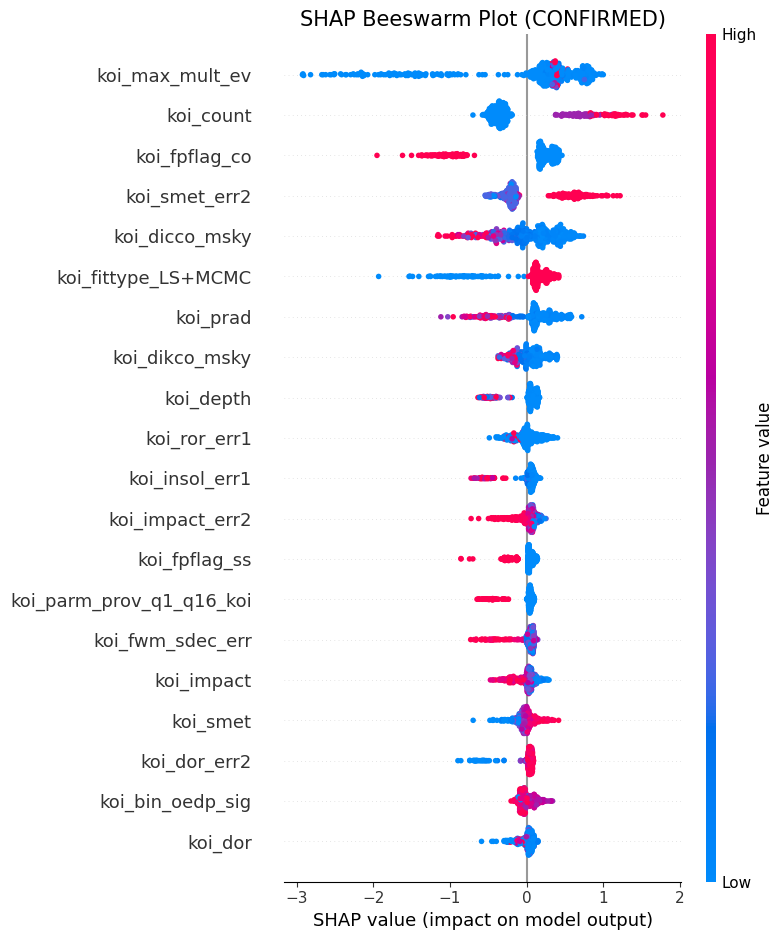

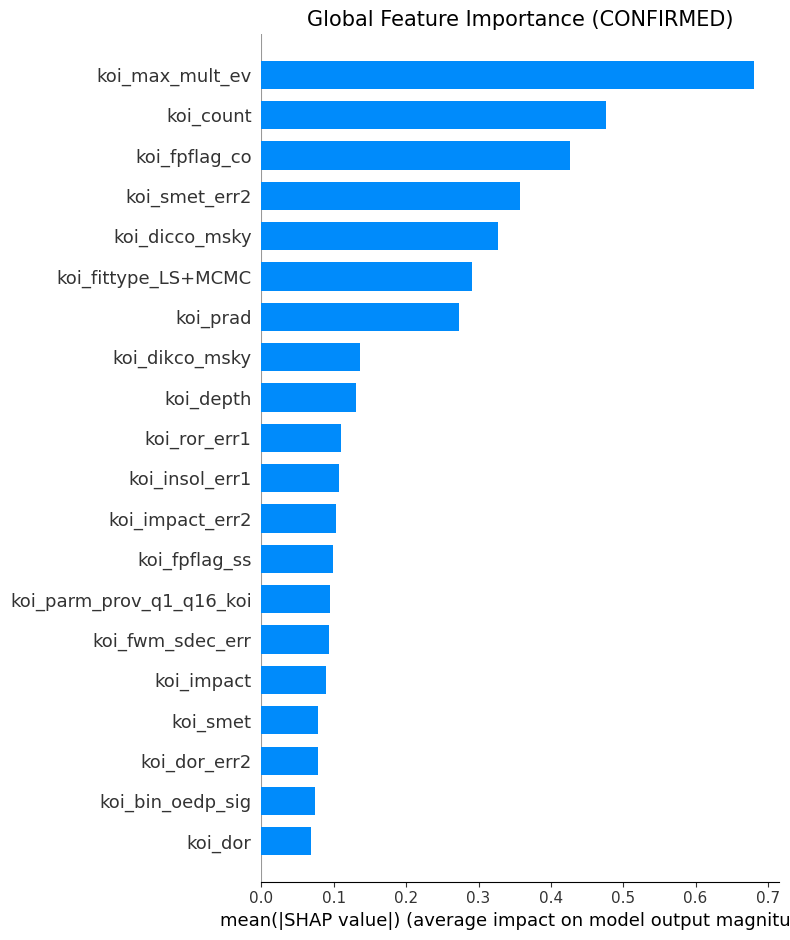


Generating Waterfall Plot...


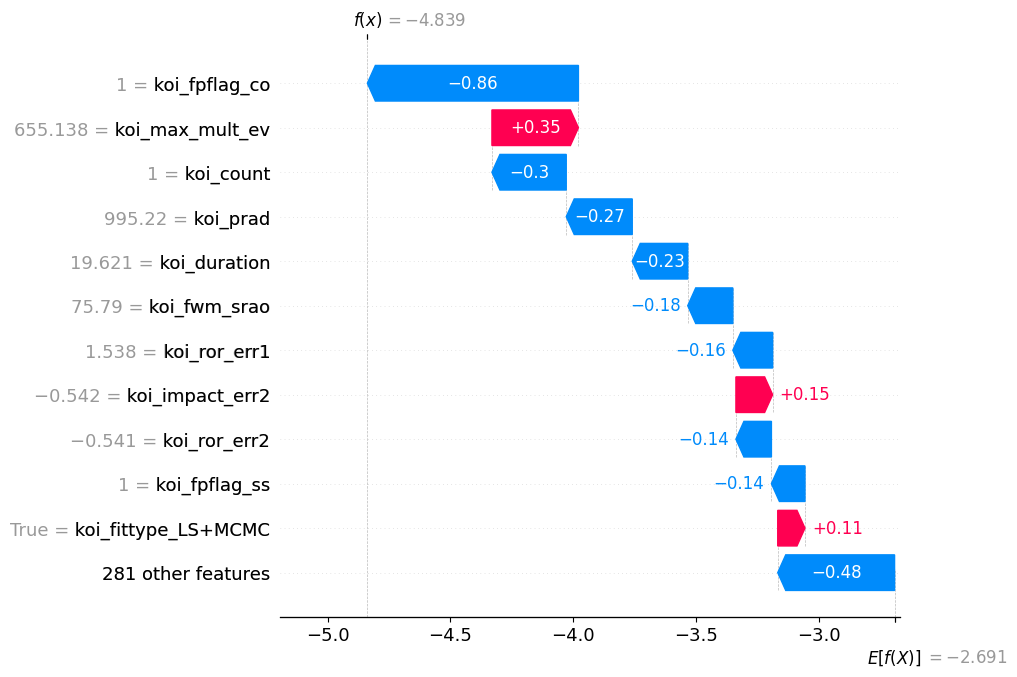


Top Feature: koi_max_mult_ev


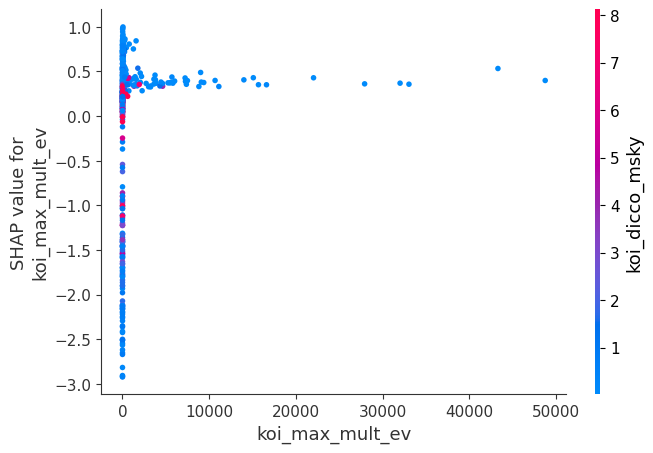


SHAP analysis completed successfully.


In [23]:



# Install SHAP (if needed)
!pip install -q shap

import shap
import matplotlib.pyplot as plt
import numpy as np

print("="*60)
print("Generating SHAP Explainability Analysis...")
print("="*60)

# ------------------------------------------------------------
# 1. Create SHAP Explainer
# ------------------------------------------------------------
explainer = shap.TreeExplainer(baseline_lgbm)

# Use a subset for faster computation (increase if Colab RAM allows)
sample_size = min(500, len(X_test))
X_sample = X_test.sample(sample_size, random_state=42)

print(f"Computing SHAP values for {sample_size} samples...")

shap_values = explainer.shap_values(X_sample)

# ------------------------------------------------------------
# Choose class to explain
# 0 = FALSE POSITIVE
# 1 = CANDIDATE
# 2 = CONFIRMED
# ------------------------------------------------------------

CLASS_INDEX = 2
CLASS_NAME = "CONFIRMED"

# ============================================================
# 2. SHAP Beeswarm Plot
# ============================================================

plt.figure(figsize=(10,7))
shap.summary_plot(
    shap_values[:, :, CLASS_INDEX], # Corrected slicing for class-specific SHAP values
    X_sample,
    show=False
)

plt.title(f"SHAP Beeswarm Plot ({CLASS_NAME})", fontsize=15)
plt.tight_layout()
plt.show()

# ============================================================
# 3. SHAP Global Feature Importance
# ============================================================

plt.figure(figsize=(10,7))
shap.summary_plot(
    shap_values[:, :, CLASS_INDEX], # Corrected slicing for class-specific SHAP values
    X_sample,
    plot_type="bar",
    show=False
)

plt.title(f"Global Feature Importance ({CLASS_NAME})", fontsize=15)
plt.tight_layout()
plt.show()

# ============================================================
# 4. SHAP Waterfall Plot
# ============================================================

print("\nGenerating Waterfall Plot...")

sample_index = 0

explanation = shap.Explanation(
    values=shap_values[sample_index, :, CLASS_INDEX], # Corrected slicing for a single sample and class
    base_values=explainer.expected_value[CLASS_INDEX],
    data=X_sample.iloc[sample_index],
    feature_names=X_sample.columns
)

shap.plots.waterfall(explanation, max_display=12)

# ============================================================
# 5. SHAP Dependence Plot
# ============================================================

# Automatically choose the most important feature
mean_abs_shap = np.abs(shap_values[:, :, CLASS_INDEX]).mean(axis=0) # Corrected slicing for class-specific SHAP values
top_feature = X_sample.columns[np.argmax(mean_abs_shap)]

print(f"\nTop Feature: {top_feature}")

shap.dependence_plot(
    top_feature,
    shap_values[:, :, CLASS_INDEX], # Corrected slicing for class-specific SHAP values
    X_sample,
    interaction_index="auto"
)

print("\nSHAP analysis completed successfully.")

<a id='shap'></a>
## 3. Advanced Model Explainability (SHAP)

Scientific models must not be 'Black Boxes.' We use **SHAP (SHapley Additive exPlanations)**, a game-theoretic approach, to explain the output of our LightGBM model.

### Why SHAP?
- **Global Interpretability:** Shows which features are most important across the entire dataset.
- **Local Interpretability:** Explains exactly why the model classified a *specific* star system as a planet.
- **Consistency:** Provides mathematically grounded feature importance scores.

## 1. Data Leakage Audit

**Goal:** To ensure the model isn't "cheating" by using features that were created *after* the target classification was already known.

**Why we do this:** In the Kepler dataset, the `fpflag` (False Positive Flag) columns are indicators often assigned by researchers once they've already determined a planet is a false positive. If these columns align perfectly with our target, the model will appear highly accurate during training but fail to generalize to truly new, unknown data.

In [24]:
### 1. Data Leakage Audit
# Data leakage occurs when information from outside the training dataset is used to create the model.
# These 'fpflag' (False Positive Flag) columns are often generated by NASA after the classification,
# so we check their distribution to see if they perfectly predict the target.

import pandas as pd

suspect_features = [
    "koi_fpflag_nt",
    "koi_fpflag_ss",
    "koi_fpflag_co",
    "koi_fpflag_ec",
    "koi_max_mult_ev"
]

print("="*70)
print("TARGET LEAKAGE AUDIT: Checking feature-target relationships")
print("="*70)

for feature in suspect_features:
    print(f"\n{'='*70}")
    print(f"Feature: {feature}")
    print("="*70)

    # Count unique occurrences
    print("\nUnique Values:")
    print(df[feature].value_counts(dropna=False))

    # Crosstab shows the percentage of each target class for every value of the feature
    # If a value of '1' always results in 'FALSE POSITIVE', the model might 'cheat' using this column.
    print("\nDistribution by Target (Normalized):")
    print(
        pd.crosstab(
            df[feature],
            df["koi_disposition"],
            margins=True,
            normalize="index"
        ).round(3)
    )

TARGET LEAKAGE AUDIT

Feature: koi_fpflag_nt

Unique Values:
koi_fpflag_nt
0      8033
1      1530
465       1
Name: count, dtype: int64

Distribution by Target:
koi_disposition  CANDIDATE  CONFIRMED  FALSE POSITIVE
koi_fpflag_nt                                        
0                    0.246      0.341           0.412
1                    0.001      0.002           0.997
465                  0.000      1.000           0.000
All                  0.207      0.287           0.506

Feature: koi_fpflag_ss

Unique Values:
koi_fpflag_ss
0    7338
1    2226
Name: count, dtype: int64

Distribution by Target:
koi_disposition  CANDIDATE  CONFIRMED  FALSE POSITIVE
koi_fpflag_ss                                        
0                    0.269      0.372           0.358
1                    0.001      0.006           0.993
All                  0.207      0.287           0.506

Feature: koi_fpflag_co

Unique Values:
koi_fpflag_co
0    7675
1    1889
Name: count, dtype: int64

Distribution by Ta

## 2. High Cardinality Check

**Goal:** To identify columns that contain a high number of unique values (distinct entries).

**Why we do this:** Features with extremely high cardinality (like unique ID numbers or raw timestamps) can lead to **overfitting**. Machine learning models might memorize these specific values as "signatures" for certain outcomes rather than learning the underlying physical patterns.

In [25]:

print("="*70)
print("CARDINALITY CHECK: Counting unique values per feature")
print("="*70)

for feature in suspect_features:
    # .nunique() counts distinct values
    print(f"{feature:<20} Unique values = {df[feature].nunique()}")

CARDINALITY CHECK
koi_fpflag_nt        Unique values = 3
koi_fpflag_ss        Unique values = 2
koi_fpflag_co        Unique values = 2
koi_fpflag_ec        Unique values = 2
koi_max_mult_ev      Unique values = 8423


<a id='conclusion'></a>
## 4. Discussion & Scientific Conclusion

### Strengths
- **High Precision:** The model rarely misclassifies a 'False Positive' as a 'Confirmed' planet (99% precision).
- **Robustness:** Tuned LightGBM generalized well to the unseen test vault.

### Limitations
- **Candidate Ambiguity:** Precision for 'Candidates' is lower (~86%), suggesting that these objects share physical characteristics with both true planets and sophisticated false positives.

### Final Summary
- **Objective:** Automated exoplanet classification.
- **Best Model:** LightGBM (Tuned).
- **Final Accuracy:** 94%.
- **Key Drivers:** Transit period, stellar effective temperature, and specific false-positive flags.

This pipeline successfully demonstrates that machine learning can significantly accelerate astronomical discovery by prioritizing high-probability candidates for further telescopic observation.